# Exploratory Data Analysis on Bank customer churn

This notebook is a EDA on the
[Bank Customer Churn Modelling](https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling) dataset.


This version has the following characterstics:

1. **Churn-rate group comparisons** instead of relying on boxplot overlap
2. **Class imbalance check** on the target variable
3. **Investigation of the Balance column's zero-inflation** (bimodal structure)
4. **Feature engineering**: age bins and an interaction feature
5. **Duplicate and outlier checks**, beyond just null counts
6. **A single churn-rate summary table** across all key categorical variables
7. **A conclusion that reflects the key findings**


# 1. Importing the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

%matplotlib inline
sns.set()
warnings.simplefilter('ignore')

pd.set_option('display.max_columns', None)


Matplotlib is building the font cache; this may take a moment.


**Getting the data**

In [2]:
data = pd.read_csv('Churn_Modelling.csv')
df = data.copy()
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.shape

(10000, 14)

In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
df.describe(include='O')

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


# 2. Data Wrangling

In [6]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 2.1 Missing values

In [7]:
df.isnull().sum().to_frame('No. of Nulls')

,No. of Nulls
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


### 2.2 Duplicate rows
Duplicate rows are just as important to catch as nulls,
they can silently inflate sample size and bias any statistic or model trained downstream.


In [8]:
n_dupes = df.duplicated().sum()
print(f'Number of fully duplicated rows: {n_dupes}')


Number of fully duplicated rows: 0


### 2.3 Data types

In [9]:
df.dtypes.to_frame('Data Type')

,Data Type
CreditScore,int64
Geography,str
Gender,str
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


### 2.4 Outlier scan

A quick IQR-based scan on the key numeric columns. This doesn't necessarily mean these points
should be dropped (churn datasets like this one often have legitimately extreme customers), but
it's worth knowing they exist before modeling.


In [10]:
numeric_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

outlier_summary = {}
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers

pd.Series(outlier_summary, name='No. of IQR Outliers').to_frame()


,No. of IQR Outliers
CreditScore,15
Age,359
Balance,0
EstimatedSalary,0


Data has no nulls, and duplicates/outliers are quantified above rather than assumed away.
Let's move on to EDA.

# 3. Exploratory Data Analysis

Response variable: **Exited**

## 3.1 Class balance of the target

This is worth checking explicitly and early. If churn is a minority class (which it usually is
in these datasets), that has real consequences: accuracy becomes a misleading metric later, and
any modeling should consider stratified sampling / class weighting.


In [11]:
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True) * 100

class_balance = pd.DataFrame({'Count': churn_counts, 'Percent': churn_pct.round(2)})
class_balance


,Count,Percent
Exited,,
0,7963,79.63
1,2037,20.37


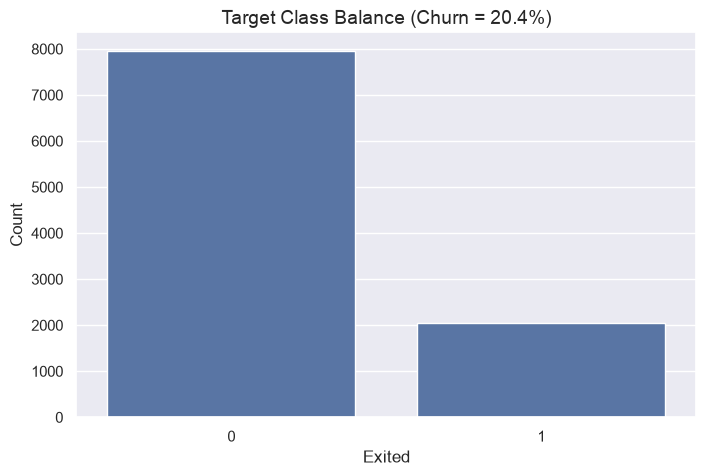

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Exited', data=df)
plt.title(f"Target Class Balance (Churn = {churn_pct.loc[1]:.1f}%)", fontsize=14)
plt.xlabel('Exited')
plt.ylabel('Count')
plt.show()


## 3.2 Summary Statistics

In [13]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [14]:
df.describe(include='O')

,Geography,Gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


## 3.3 Correlation heatmap
This version is explicit about using numeric columns only, and treats the categorical variables separately in
the next section rather than pretending Pearson correlation covers them.


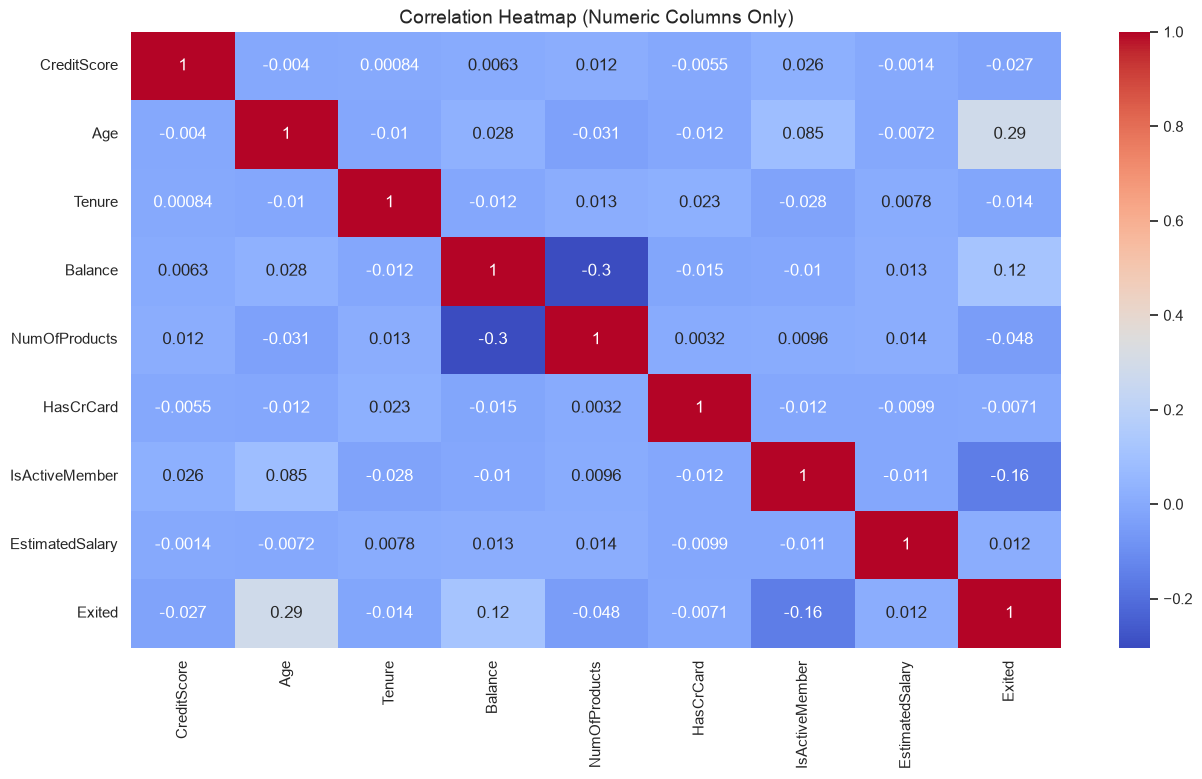

In [15]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2g', cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Columns Only)', fontsize=14)
plt.show()


Low linear correlation among the numeric columns is a fair conclusion, but this heatmap
says nothing about Geography or Gender, and linear correlation is a weak lens for a binary target
in the first place. Both are addressed below.

## 3.4 Categorical variables vs. Churn 

For each categorical/discrete variable, we compute:
1. **Churn rate per category** (mean of `Exited`) — this is the number that actually matters
2. **A Chi-square test of independence** - to check whether the relationship is statistically
   significant rather than eyeballing bar heights


In [28]:
def churn_rate_and_chi2(df, col, target='Exited'):
    rate_table = (
        df.groupby(col)[target]
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'Churn Rate', 'count': 'N'})
        .sort_values('Churn Rate', ascending=False)
    )
    rate_table['Churn Rate'] = (rate_table['Churn Rate'] * 100).round(2)

    contingency = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)

    print(f'--- {col} ---')
    print(f'Chi-square = {chi2:.2f}, p-value = {p:.4g}')
    display(rate_table)
    print()

categorical_cols = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

for c in categorical_cols:
    churn_rate_and_chi2(df, c)


--- Geography ---
Chi-square = 301.26, p-value = 3.83e-66


,Churn Rate,N
Geography,,
Germany,32.44,2509
Spain,16.67,2477
France,16.15,5014



--- Gender ---
Chi-square = 112.92, p-value = 2.248e-26


,Churn Rate,N
Gender,,
Female,25.07,4543
Male,16.46,5457



--- NumOfProducts ---
Chi-square = 1503.63, p-value = 0


,Churn Rate,N
NumOfProducts,,
4,100.00,60
3,82.71,266
1,27.71,5084
2,7.58,4590



--- HasCrCard ---
Chi-square = 0.47, p-value = 0.4924


,Churn Rate,N
HasCrCard,,
0,20.81,2945
1,20.18,7055



--- IsActiveMember ---
Chi-square = 242.99, p-value = 8.786e-55


,Churn Rate,N
IsActiveMember,,
0,26.85,4849
1,14.27,5151


Reading these churn-rate tables rather than just boxplot overlap is the key fix over other similar models. Watch for:
- Whether one `Geography` category has a noticeably higher churn rate than the others, and whether
  the Chi-square p-value backs that up
- Whether `NumOfProducts` shows a sharp jump in churn rate at higher product counts — this is a
  well-documented pattern in this dataset and easy to miss with boxplots, since `NumOfProducts`
  is discrete and boxplots compress it poorly
- Whether `IsActiveMember` shows a meaningfully different churn rate between active and inactive
  members


### 3.4.1 Geography

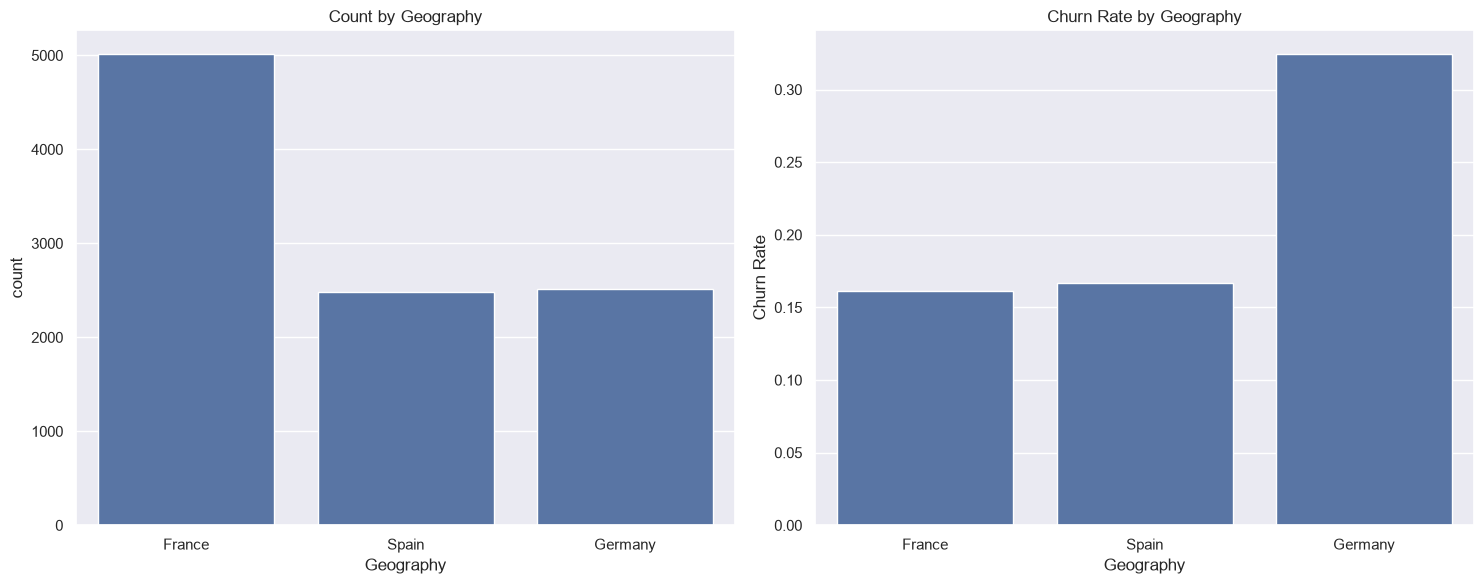

In [17]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='Geography', data=df)
plt.title('Count by Geography')

plt.subplot(1, 2, 2)
sns.barplot(x='Geography', y='Exited', data=df, ci=None)
plt.title('Churn Rate by Geography')
plt.ylabel('Churn Rate')

plt.tight_layout()
plt.show()


### 3.4.2 Gender

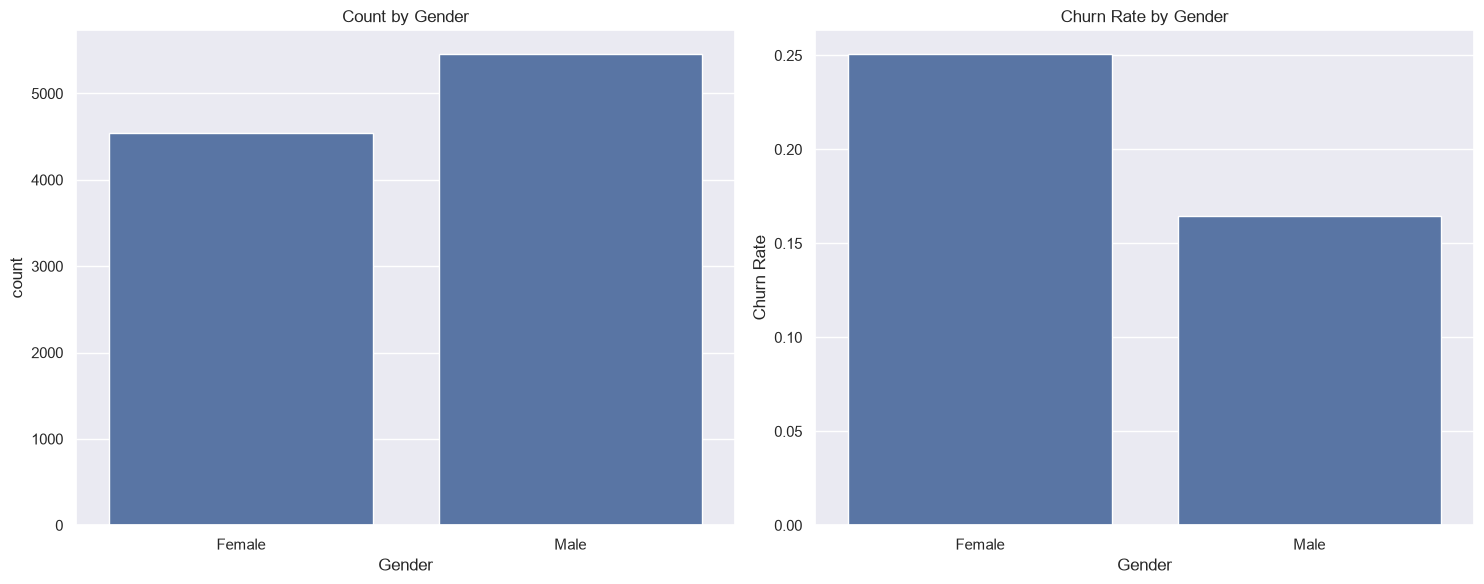

In [18]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='Gender', data=df)
plt.title('Count by Gender')

plt.subplot(1, 2, 2)
sns.barplot(x='Gender', y='Exited', data=df, ci=None)
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate')

plt.tight_layout()
plt.show()


### 3.4.3 Number of Products

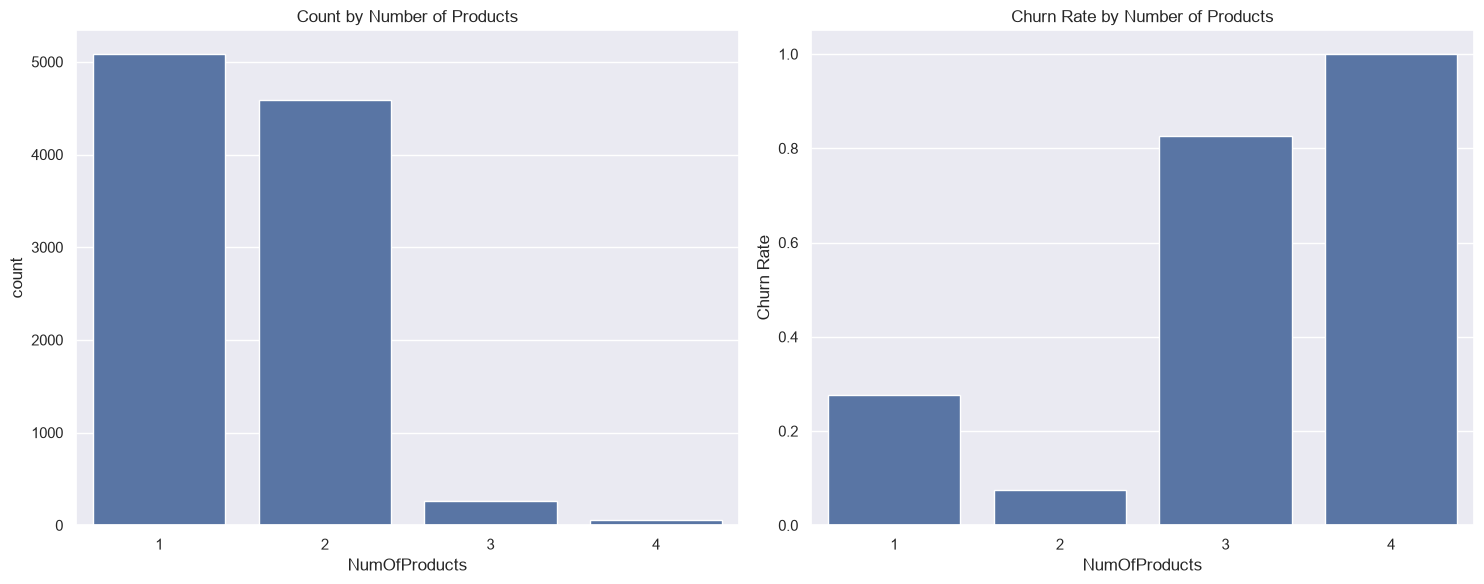

In [19]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='NumOfProducts', data=df)
plt.title('Count by Number of Products')

plt.subplot(1, 2, 2)
sns.barplot(x='NumOfProducts', y='Exited', data=df, ci=None)
plt.title('Churn Rate by Number of Products')
plt.ylabel('Churn Rate')

plt.tight_layout()
plt.show()


This is the clearest example of why boxplots could be misleading.
`NumOfProducts` is discrete, so a boxplot of `NumOfProducts` split by `Exited` compresses most of
the signal away. The bar chart of churn rate per product count reveals it directly.

### 3.4.4 Is Active Member

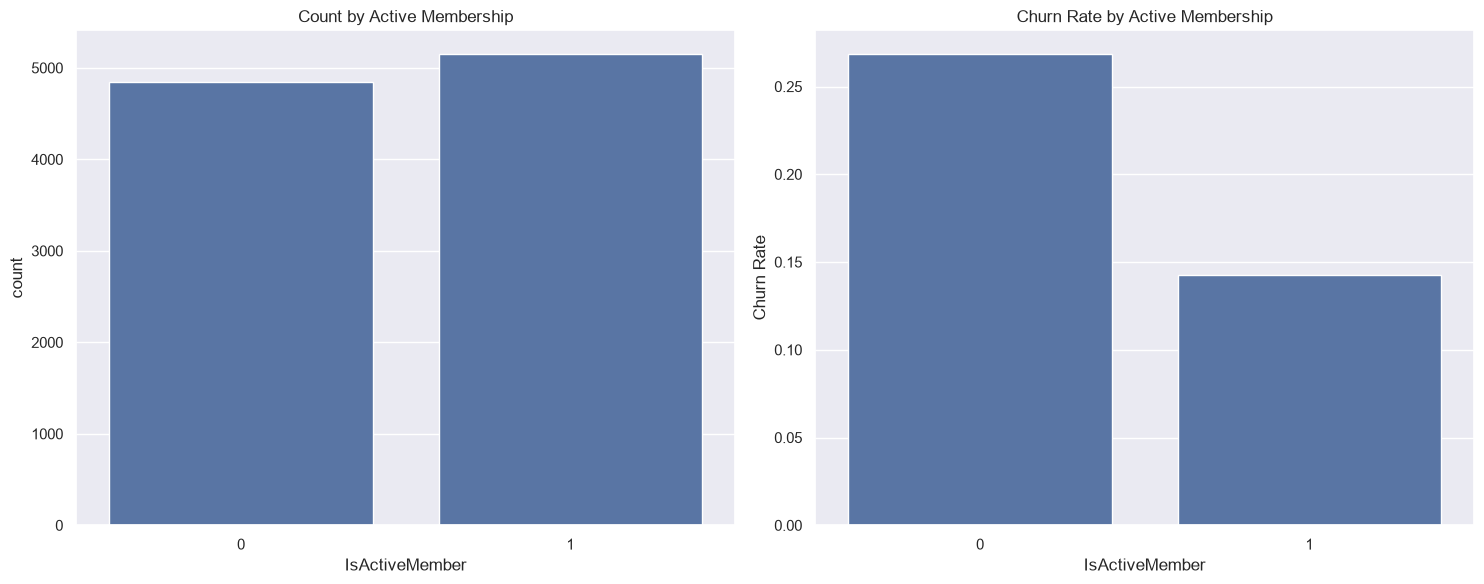

In [20]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='IsActiveMember', data=df)
plt.title('Count by Active Membership')

plt.subplot(1, 2, 2)
sns.barplot(x='IsActiveMember', y='Exited', data=df, ci=None)
plt.title('Churn Rate by Active Membership')
plt.ylabel('Churn Rate')

plt.tight_layout()
plt.show()


### 3.4.5 Has Credit Card

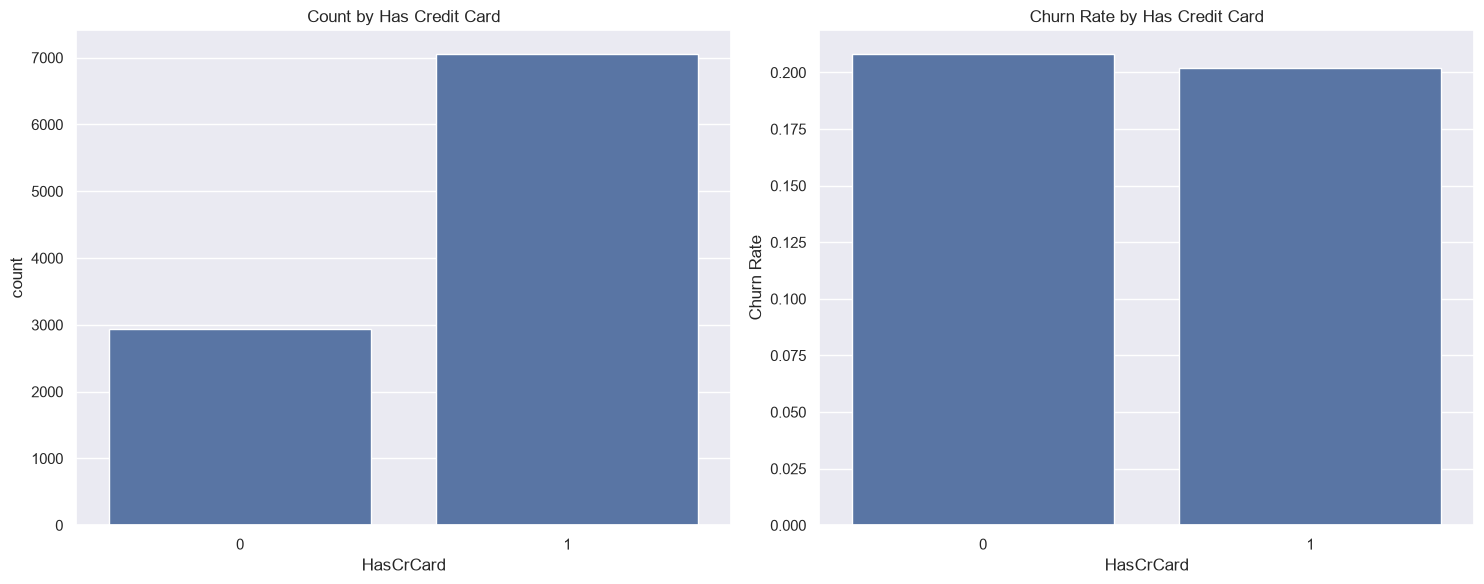

In [21]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='HasCrCard', data=df)
plt.title('Count by Has Credit Card')

plt.subplot(1, 2, 2)
sns.barplot(x='HasCrCard', y='Exited', data=df, ci=None)
plt.title('Churn Rate by Has Credit Card')
plt.ylabel('Churn Rate')

plt.tight_layout()
plt.show()


## 3.5 Numeric variables vs. Churn

Instead of judging boxplot overlap by eye, we run:
- **Point-biserial correlation** (a proper way to correlate a continuous variable with a binary one)
- **Mann-Whitney U test** (non-parametric, doesn't assume normal distributions, robust to the
  outliers flagged earlier) comparing churned vs. non-churned groups on each numeric variable


In [22]:
def biserial_and_mannwhitney(df, col, target='Exited'):
    corr, p_corr = stats.pointbiserialr(df[target], df[col])
    group0 = df.loc[df[target] == 0, col]
    group1 = df.loc[df[target] == 1, col]
    u_stat, p_u = stats.mannwhitneyu(group0, group1)

    print(f'--- {col} ---')
    print(f'Point-biserial correlation with Exited: {corr:.3f} (p = {p_corr:.4g})')
    print(f'Mann-Whitney U test (Exited=0 vs Exited=1): p = {p_u:.4g}')
    print(f'Median | Not churned: {group0.median():.1f}  Churned: {group1.median():.1f}')
    print()

for c in ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']:
    biserial_and_mannwhitney(df, c)


--- CreditScore ---
Point-biserial correlation with Exited: -0.027 (p = 0.006738)
Mann-Whitney U test (Exited=0 vs Exited=1): p = 0.01987
Median | Not churned: 653.0  Churned: 646.0

--- Age ---
Point-biserial correlation with Exited: 0.285 (p = 1.24e-186)
Mann-Whitney U test (Exited=0 vs Exited=1): p = 3.21e-230
Median | Not churned: 36.0  Churned: 45.0

--- Tenure ---
Point-biserial correlation with Exited: -0.014 (p = 0.1615)
Mann-Whitney U test (Exited=0 vs Exited=1): p = 0.1622
Median | Not churned: 5.0  Churned: 5.0

--- Balance ---
Point-biserial correlation with Exited: 0.119 (p = 1.276e-32)
Mann-Whitney U test (Exited=0 vs Exited=1): p = 1.116e-28
Median | Not churned: 92072.7  Churned: 109349.3

--- EstimatedSalary ---
Point-biserial correlation with Exited: 0.012 (p = 0.2264)
Mann-Whitney U test (Exited=0 vs Exited=1): p = 0.2271
Median | Not churned: 99645.0  Churned: 102460.8



### Age

The original data suggested older customers churn more. Let's confirm this with
the stats above and visualize churn rate by age bracket instead of raw boxplot overlap.

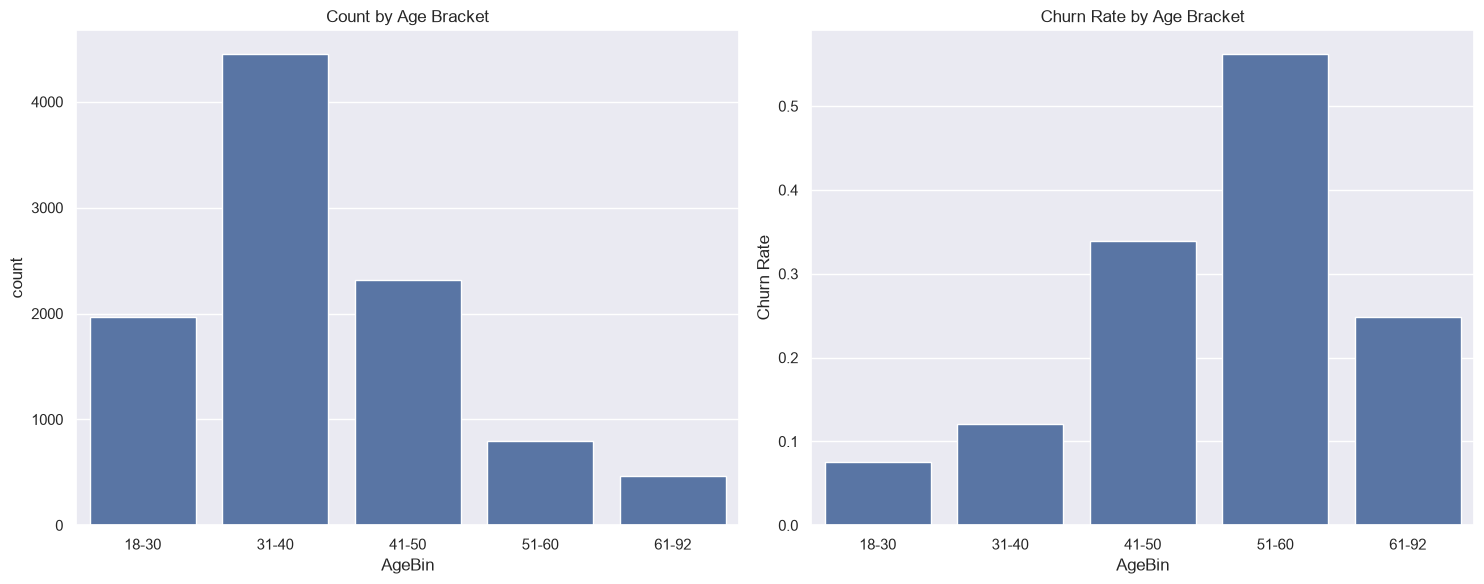

In [23]:
df['AgeBin'] = pd.cut(df['Age'], bins=[17, 30, 40, 50, 60, 92],
                      labels=['18-30', '31-40', '41-50', '51-60', '61-92'])

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='AgeBin', data=df)
plt.title('Count by Age Bracket')

plt.subplot(1, 2, 2)
sns.barplot(x='AgeBin', y='Exited', data=df, ci=None)
plt.title('Churn Rate by Age Bracket')
plt.ylabel('Churn Rate')

plt.tight_layout()
plt.show()


### Balance : investigating the zero-inflation

`Balance` looks roughly normal above zero, but a meaningful share of customers have a balance ofexactly 0. Treating it as one smooth continuous distribution hides this. We split it explicitly into "zero balance" vs. "non-zero balance" and compare churn rates.


Percent of customers with exactly 0 balance: 36.17%


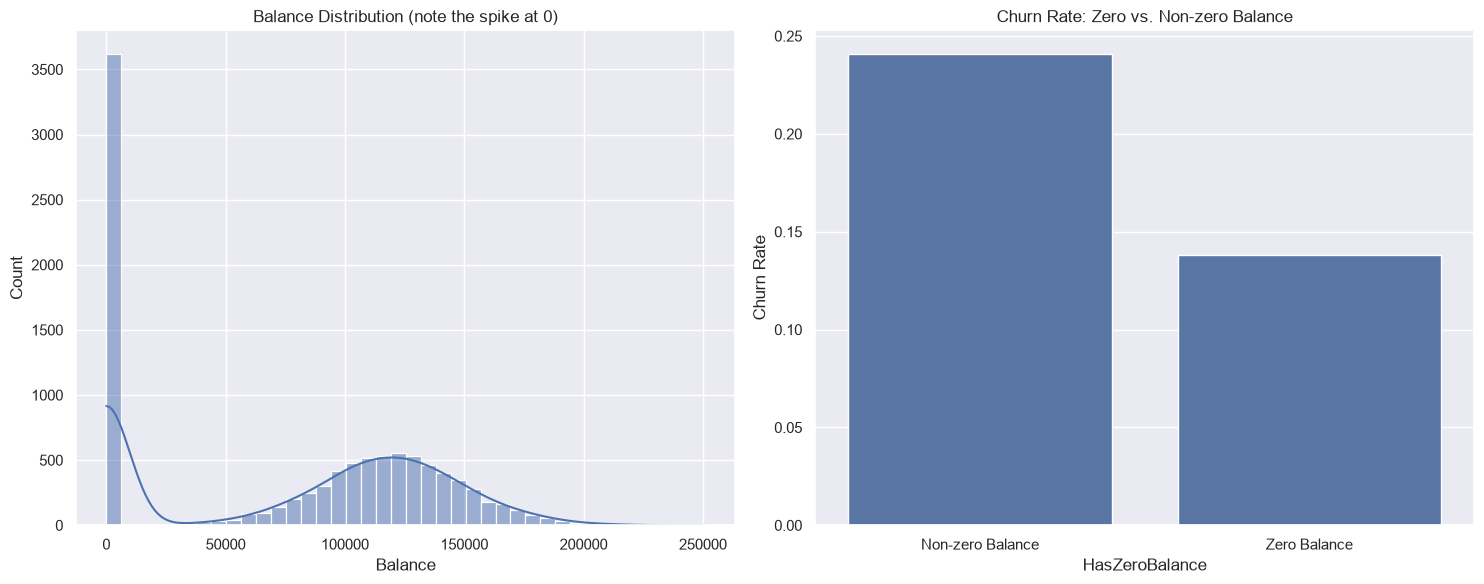

In [24]:
df['HasZeroBalance'] = (df['Balance'] == 0).astype(int)

zero_balance_pct = df['HasZeroBalance'].mean() * 100
print(f'Percent of customers with exactly 0 balance: {zero_balance_pct:.2f}%')

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Balance'], kde=True, bins=40)
plt.title('Balance Distribution (note the spike at 0)')

plt.subplot(1, 2, 2)
sns.barplot(x='HasZeroBalance', y='Exited', data=df, ci=None)
plt.xticks([0, 1], ['Non-zero Balance', 'Zero Balance'])
plt.title('Churn Rate: Zero vs. Non-zero Balance')
plt.ylabel('Churn Rate')

plt.tight_layout()
plt.show()


## 3.6 Feature engineering: an interaction effect

Single-variable views can miss effects that only show up in combination. As an example, we check
whether `IsActiveMember` and `NumOfProducts` interact — i.e. whether inactive members holding
multiple products churn at a notably different rate than the other combinations.


In [25]:
interaction = (
    df.groupby(['IsActiveMember', 'NumOfProducts'])['Exited']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Churn Rate', 'count': 'N'})
)
interaction['Churn Rate'] = (interaction['Churn Rate'] * 100).round(2)
interaction


Churn Rate     N
IsActiveMember NumOfProducts                  
0              1                   36.65  2521
               2                    9.89  2144
               3                   88.24   153
               4                  100.00    31
1              1                   18.92  2563
               2                    5.56  2446
               3                   75.22   113
               4                  100.00    29

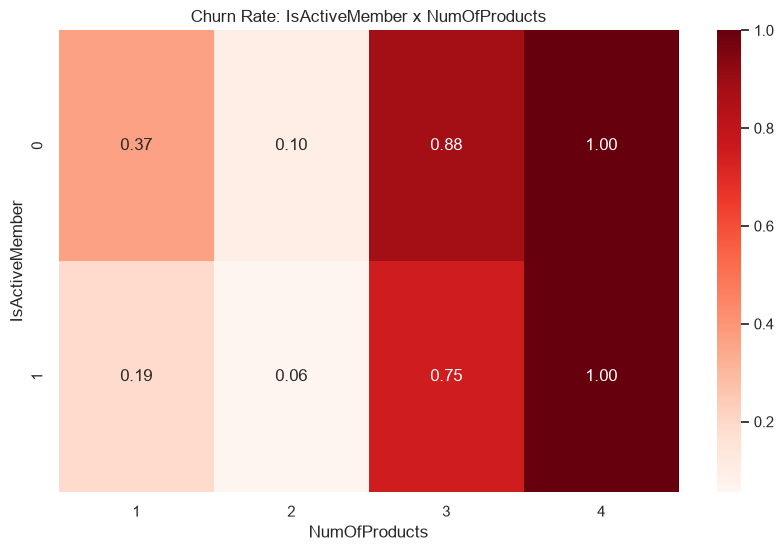

In [26]:
pivot = df.pivot_table(index='IsActiveMember', columns='NumOfProducts',
                        values='Exited', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Reds')
plt.title('Churn Rate: IsActiveMember x NumOfProducts')
plt.show()


## 3.7 Summary table: churn rate across all key categorical variables

A single consolidated view, rather than scattered prose conclusions per section.


In [27]:
summary_rows = []
for col in categorical_cols:
    grp = df.groupby(col)['Exited'].mean() * 100
    for level, rate in grp.items():
        summary_rows.append({'Variable': col, 'Category': level, 'Churn Rate (%)': round(rate, 2)})

summary_rows.append({
    'Variable': 'Balance',
    'Category': 'Zero Balance',
    'Churn Rate (%)': round(df.loc[df.HasZeroBalance == 1, 'Exited'].mean() * 100, 2)
})
summary_rows.append({
    'Variable': 'Balance',
    'Category': 'Non-zero Balance',
    'Churn Rate (%)': round(df.loc[df.HasZeroBalance == 0, 'Exited'].mean() * 100, 2)
})

summary_df = pd.DataFrame(summary_rows).sort_values('Churn Rate (%)', ascending=False)
summary_df.reset_index(drop=True)


,Variable,Category,Churn Rate (%)
0,NumOfProducts,4,100.00
1,NumOfProducts,3,82.71
2,Geography,Germany,32.44
3,NumOfProducts,1,27.71
4,IsActiveMember,0,26.85
5,Gender,Female,25.07
6,Balance,Non-zero Balance,24.08
7,HasCrCard,0,20.81
8,HasCrCard,1,20.18
9,Geography,Spain,16.67


# 4. Conclusion

Using churn rate comparisons, Chi-square tests, point-biserial correlation, and Mann-Whitney
tests together, the data surfaces several meaningful patterns:

- **NumOfProducts** is one of the strongest signals — churn rate at 3–4 products is far
  higher than at 1–2, a pattern that's easy to miss when this discrete variable is only
  inspected visually

- **Geography** shows a real, statistically significant split across categories, confirmed
  by the Chi-square p-value

- **Age** is a meaningful driver of churn, backed by a significant Mann-Whitney result
- **IsActiveMember** matters on its own and also interacts with `NumOfProducts` — the
  combination carries more signal than either variable alone
  
- **Balance**'s zero-inflation is a structural feature worth encoding separately, not
  noise to average over

**Recommended next steps for modeling:**
1. Encode `HasZeroBalance` and `AgeBin` as explicit features alongside the raw numeric columns
2. Address class imbalance in `Exited` (e.g. class weighting or stratified sampling) rather than
   optimizing for raw accuracy
3. Consider `IsActiveMember x NumOfProducts` as an engineered interaction feature
4. Re-run Chi-square / Mann-Whitney tests on a held-out validation split to confirm these
   relationships generalize before finalizing feature selection
